**NAME:** Suprith Kishore<br>
**MATRICULATION NO:** 34208577

In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv(r"C:\Users\supri\Desktop\data visualization\train.csv")
data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


**Q:** Check the data type of each column. How many rows are there in the dataset 
? Does the dataset contain any missing values

In [4]:
data.dtypes

datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

In [5]:
print("number of rows = ",len(data))

number of rows =  10886


In [6]:
data.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


**Q:** Using the date column, create new columns for: year, month, day of the week and hour of the day.


In [8]:
data['datetime'] = pd.to_datetime(data['datetime'])
data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day_of_the_week'] = data['datetime'].dt.day_name()
data['hour'] = data['datetime'].dt.hour
data[['datetime','year','month','day_of_the_week','hour']].head()



,datetime,year,month,day_of_the_week,hour
0,2011-01-01 00:00:00,2011,1,Saturday,0
1,2011-01-01 01:00:00,2011,1,Saturday,1
2,2011-01-01 02:00:00,2011,1,Saturday,2
3,2011-01-01 03:00:00,2011,1,Saturday,3
4,2011-01-01 04:00:00,2011,1,Saturday,4


**Q:** Rename the values in the season column to spring, summer, fall and winter

In [9]:
print(data['season'].unique())

[1 2 3 4]


In [10]:
data['season']= data['season'].astype(int)
season_map={
    1: 'spring',
    2: 'summer',
    3: 'fall',
    4: 'winter'
}


data['season'] = data['season'].map(season_map)
data


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day_of_the_week,hour
0,2011-01-01 00:00:00,spring,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011,1,Saturday,0
1,2011-01-01 01:00:00,spring,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011,1,Saturday,1
2,2011-01-01 02:00:00,spring,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011,1,Saturday,2
3,2011-01-01 03:00:00,spring,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011,1,Saturday,3
4,2011-01-01 04:00:00,spring,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011,1,Saturday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,winter,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,12,Wednesday,19
10882,2012-12-19 20:00:00,winter,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,12,Wednesday,20
10883,2012-12-19 21:00:00,winter,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,Wednesday,21
10884,2012-12-19 22:00:00,winter,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,Wednesday,22


**Q:** Calculate the total number of casual and registered bikes rented in the years 
2011 and 2012.

In [11]:
total = data.groupby('year')[['casual', 'registered']].sum()
total


,casual,registered
year,,
2011,155817,626162
2012,236318,1067179


**Q:**  Calculate the mean of the hourly total rentals count by season. Which season 
has the highest mean ?

In [12]:
mean_season = data.groupby('season')[['count']].mean()
mean_season


,count
season,
fall,234.417124
spring,116.343261
summer,215.251372
winter,198.988296


In [13]:
print('the season having highest mean =',mean_season.idxmax())

the season having highest mean = count    fall
dtype: object


**Q:** Are more bikes rented by registered users on working or non-working days ?  
Does the answer differ for non-registered users ? Is the answer the same for 
both years ?     

In [14]:
bike_rented_workingday = data.groupby('workingday')[['registered']].sum()
bike_rented_workingday

,registered
workingday,
0,448835
1,1244506


In [15]:
bike_rented_non_workingday = data.groupby('workingday')[['casual']].sum()
bike_rented_non_workingday

,casual
workingday,
0,206037
1,186098


In [16]:
yearly = data.groupby(['year', 'workingday'])[['registered', 'casual']].sum()
print(yearly)


                 registered  casual
year workingday                    
2011 0               167492   83099
     1               458670   72718
2012 0               281343  122938
     1               785836  113380


**ANS:**
as we can see,The registered user uses the rental bike on the working day(1)more,than the non working day(0)<br>
casual user uses  the rental bike on the non working day(0)more compare to working day(1)<br>
Tis pattern as visble for both the years 2011 and 2012

**Q:** Which months in the year 2011 have the highest and the lowest total number of 
bikes rented ? Repeat for the year 2012

In [17]:
month_map = {
    1:'jan',
    2:'feb',
    3:'Mar',
    4:'apr',
    5:'may',
    6:'jun',
    7:'jul',
    8:'aug',
    9:'sep',
    10:'oct',
    11:'nov',
    12:'dec'
}
data['month'] = data['month'].map(month_map)
data_2011 = data[data['year'] == 2011]
year_2011 = data_2011.groupby('month')['count'].sum()

print('highest number of bike rented in 2011 =',year_2011.idxmax(),year_2011.max())
print('lowest number of bike rented in 2011 =',year_2011.idxmin(),year_2011.min())

#for year 2012
data_2012 = data[data['year'] == 2012]
year_2012 = data_2012.groupby('month')['count'].sum()
print('highest number of bike rented in 2011 =',year_2012.idxmax(),year_2012.max())
print('lowest number of bike rented in 2011 =',year_2012.idxmin(),year_2012.min())


highest number of bike rented in 2011 = jul 92848
lowest number of bike rented in 2011 = jan 23552
highest number of bike rented in 2011 = sep 133425
lowest number of bike rented in 2011 = jan 56332


**Q:** Which type of weather have the highest and lowest mean of the hourly total 
rentals count ?

In [18]:
weather_mean = data.groupby('weather')['count'].mean()
print(weather_mean)
print('highest mean rental', weather_mean.idxmax(),weather_mean.max())
print('lowest mean rental', weather_mean.idxmin(),weather_mean.min())






weather
1    205.236791
2    178.955540
3    118.846333
4    164.000000
Name: count, dtype: float64
highest mean rental 1 205.23679087875416
lowest mean rental 3 118.84633294528521


**Q:** Calculate the correlation between the hourly total rentals count and all the 
numerical columns in the dataset. Which column has the highest correlation 
with the total rentals count ?

In [19]:
numeric_data = data.select_dtypes(include='number')
correlation_matrix = numeric_data.corr()
count_corr = correlation_matrix['count'].drop('count')
print(count_corr)
print("Highest correlation with total rentals:", count_corr.idxmax(), count_corr.max())


holiday      -0.005393
workingday    0.011594
weather      -0.128655
temp          0.394454
atemp         0.389784
humidity     -0.317371
windspeed     0.101369
casual        0.690414
registered    0.970948
year          0.260403
hour          0.400601
Name: count, dtype: float64
Highest correlation with total rentals: registered 0.9709481058098266


**Q:** Create a new categorical column called day_period, which can take four 
possible values: night, morning, afternoon and evening. These values 
correspond to the following binning of the hour column: 0-6: night, 6-12:
morning, 12-6: afternoon, 6-24:evening.

In [20]:
bins = [0,6,12,18,24]
labels = ['night','morning','afternoon', 'evening']
data['day_period']= pd.cut(data['hour'], bins=bins, labels=labels,right=False)
print(data[['hour','day_period']])

       hour day_period
0         0      night
1         1      night
2         2      night
3         3      night
4         4      night
...     ...        ...
10881    19    evening
10882    20    evening
10883    21    evening
10884    22    evening
10885    23    evening

[10886 rows x 2 columns]


**Q:** Generate a pivot table for the mean of the hourly total rentals count, with the 
index set to the day period and the column set to the working day column. 
What can you observe from the table ?

In [21]:
pivot_tabel = data.pivot_table(values='count',index ='day_period',columns='workingday')
print(pivot_tabel)

workingday           0           1
day_period                        
night        44.052083   16.217582
morning     157.772414  234.353763
afternoon   371.022989  266.196141
evening     180.182759  251.054662


C:\Users\supri\AppData\Local\Temp\ipykernel_30380\637303844.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_tabel = data.pivot_table(values='count',index ='day_period',columns='workingday')


**ANS:**
 as we can see from the above pivot table<br>
night(0)which is non working day as higher rent compare to 1(working day)<br>
morning(0)whis is non working day as less rent compare to 1(working day)<br>
afternoon(0)whis is non working day as higher rent compare to 1(working day)<br>
evening(0)whis is non working day as higher rent compare to 1(working day)<br>
so we can conclude that working day peak in the moring and evening,non working day peak in the afternoon,night are low overall but relatively higher on weekends

**Assignment 2: Data visualization**

1. Plot the distributions of all the numerical columns in the dataset using 
histograms.

In [22]:
data.dtypes

datetime           datetime64[ns]
season                     object
holiday                     int64
workingday                  int64
weather                     int64
temp                      float64
atemp                     float64
humidity                    int64
windspeed                 float64
casual                      int64
registered                  int64
count                       int64
year                        int32
month                      object
day_of_the_week            object
hour                        int32
day_period               category
dtype: object

In [23]:
numeric_cols = data.select_dtypes(include=['int64','int32','float64'])
numeric_cols

,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,hour
0,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011,0
1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011,1
2,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011,2
3,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011,3
4,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011,4
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,19
10882,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,20
10883,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,21
10884,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,22


array([[<Axes: title={'center': 'holiday'}>,
        <Axes: title={'center': 'workingday'}>,
        <Axes: title={'center': 'weather'}>],
       [<Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'humidity'}>],
       [<Axes: title={'center': 'windspeed'}>,
        <Axes: title={'center': 'casual'}>,
        <Axes: title={'center': 'registered'}>],
       [<Axes: title={'center': 'count'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'hour'}>]], dtype=object)

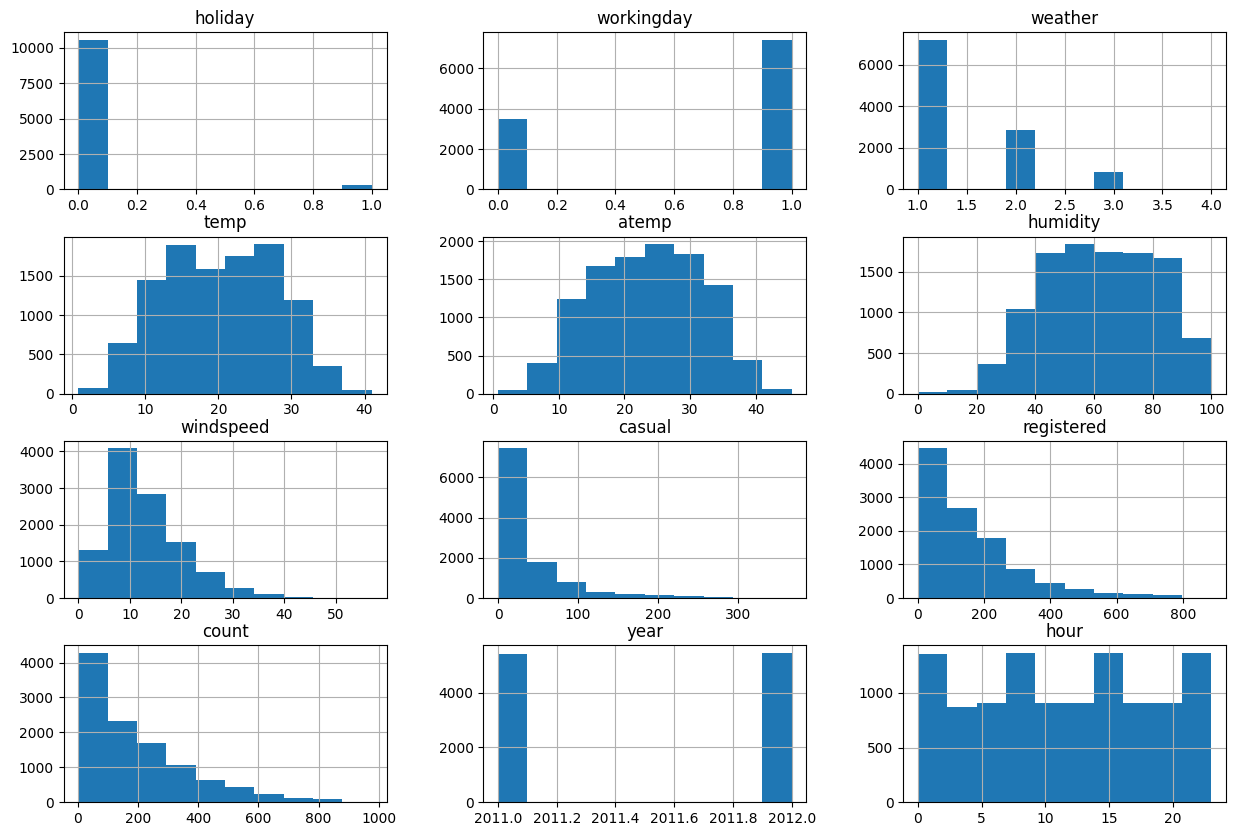

In [24]:

numeric_cols.hist(figsize=(15,10))

2.Plot the distributions of all the numerical columns in the dataset using box 
plots

<Axes: >

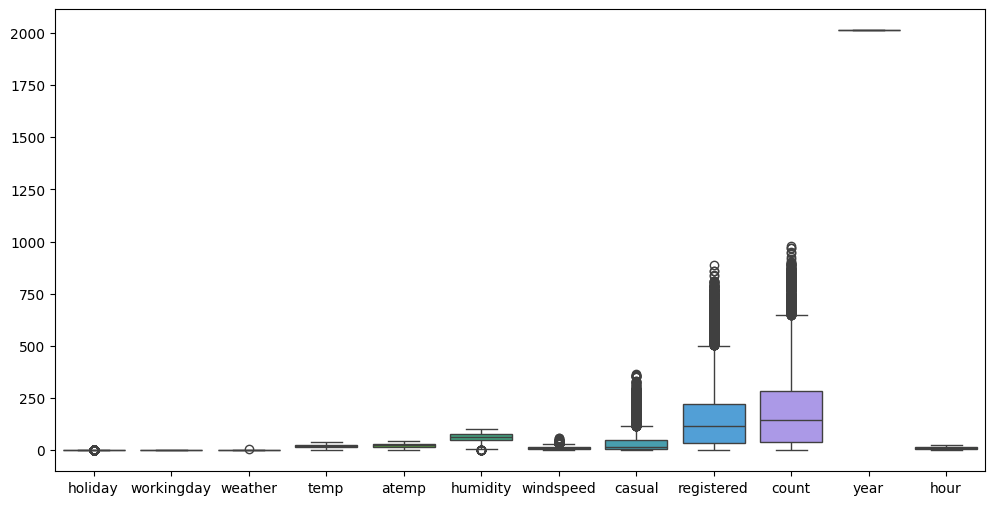

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(data=numeric_cols)

3.Plot the the mean of the hourly total rentals count for working and non
working days.

In [26]:
data.dtypes

datetime           datetime64[ns]
season                     object
holiday                     int64
workingday                  int64
weather                     int64
temp                      float64
atemp                     float64
humidity                    int64
windspeed                 float64
casual                      int64
registered                  int64
count                       int64
year                        int32
month                      object
day_of_the_week            object
hour                        int32
day_period               category
dtype: object

<Axes: xlabel='hour', ylabel='count'>

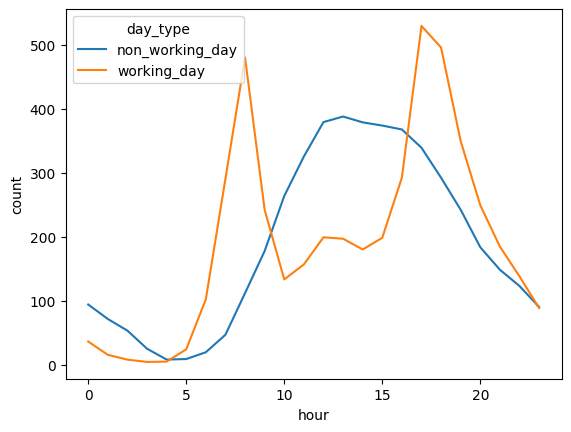

In [27]:
mean_counts = data.groupby(['hour','workingday'])['count'].mean().reset_index()
mean_counts['day_type']= mean_counts['workingday'].map({0:'non_working_day',1:'working_day'})
sns.lineplot(data=mean_counts,x='hour',y='count',hue='day_type')

4.Plot the the mean of the hourly total rentals count for the different months for 
both years combined.

Text(0.5, 1.0, 'Mean Hourly Rentals Across Months (Both Years Combined)')

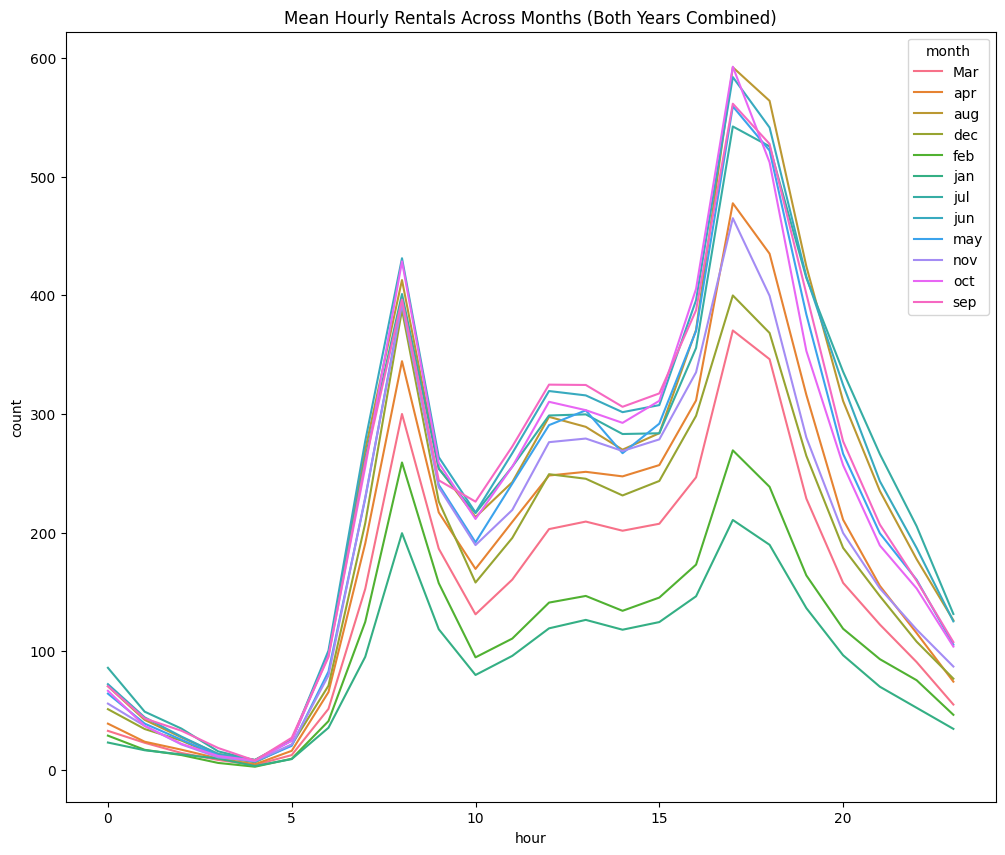

In [28]:
m_mean_counts = data.groupby(['hour','month'])['count'].mean().reset_index()
plt.figure(figsize=(12,10))
sns.lineplot(data=m_mean_counts,x='hour',y='count',hue='month')
plt.title("Mean Hourly Rentals Across Months (Both Years Combined)")

5.Plot the the mean of the hourly total rentals count for the different months for 
both years separately in a multi-panel figure.

Text(0.5, 1.0, '2012')

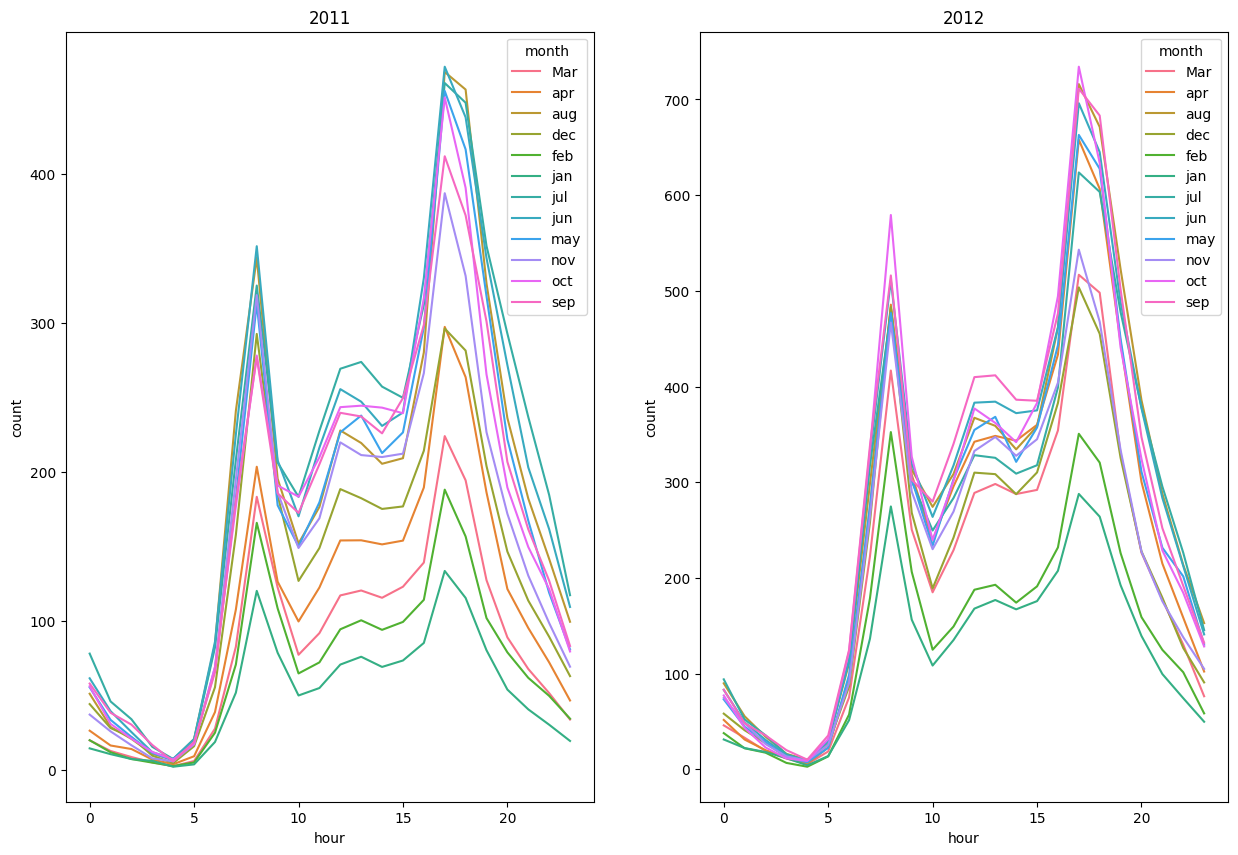

In [29]:
fig , axes= plt.subplots(1,2,figsize=(15,10))
data_2011 = data[data['year']==2011]
mean_counts = data_2011.groupby(['hour','month'])['count'].mean().reset_index()
sns.lineplot(data=mean_counts,x='hour',y='count',hue='month',ax=axes[0])
axes[0].set_title('2011')
#for 2012
data_2012 = data[data['year']==2012]
mean_counts = data_2012.groupby(['hour','month'])['count'].mean().reset_index()
sns.lineplot(data=mean_counts,x='hour',y='count',hue='month',ax=axes[1])
axes[1].set_title('2012')



6.Plot the the mean and the 95% confidence interval of the hourly total rentals 
count for the four different weather categories. What can you observe ?

In [30]:
print(data.season.unique())
print(data.weather.unique())
# data.head()

['spring' 'summer' 'fall' 'winter']
[1 2 3 4]


In [31]:
weather_map={
    1:'spring',
    2:'summer',
    3:'fall',
    4:'winter'
}
data['weather_label']=data['weather'].map(weather_map)
data.weather_label.unique()


array(['spring', 'summer', 'fall', 'winter'], dtype=object)

<Axes: xlabel='hour', ylabel='count'>

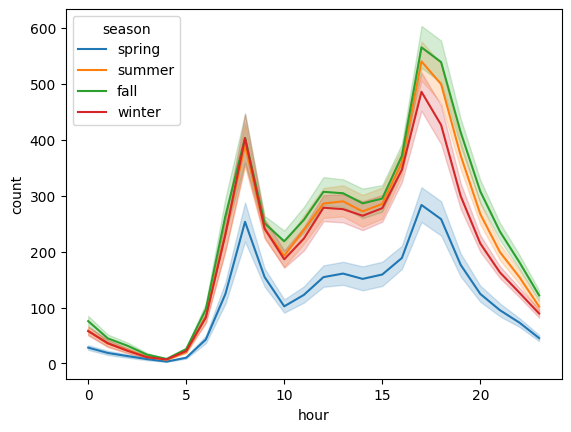

In [45]:
sns.lineplot(data=data,x='hour',y='count',hue='season',errorbar=('ci',95))


**ANS:** from the above graph we can conclude that:<br>  Summer and fall show the highest rental counts, especially during peak hours.<br>
Spring is slightly lower but still active.<br>
Winter has the lowest counts, with flatter curves and less pronounced peaks.<br>


7.Plot the the mean of the hourly total rentals count versus the hour of the day. 
Which hours of the day have the highest rentals count ?


<Axes: xlabel='hour', ylabel='count'>

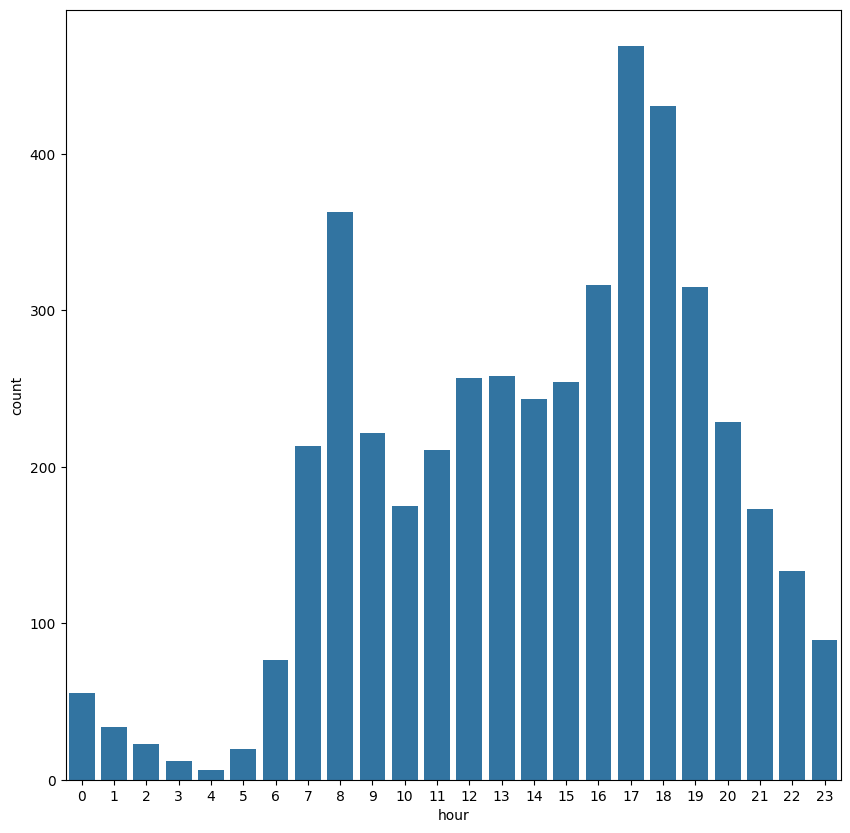

In [33]:
mean_count= data.groupby(['hour'])['count'].mean().reset_index()
plt.figure(figsize=(10,10))
sns.barplot(data=mean_count,x='hour',y='count')

**ANS:**  17:00 as  the highest hour count 

8.Repeat the plot in 7 for different days of the week. What patterns can you 
observe ?

<Axes: xlabel='hour', ylabel='count'>

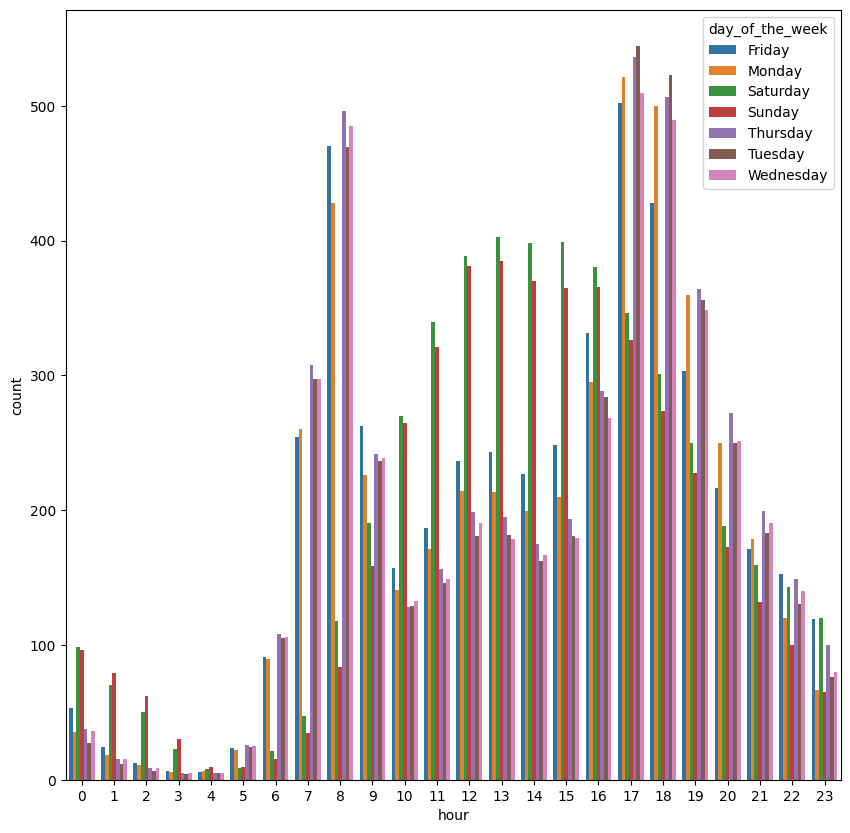

In [34]:
mean_count = data.groupby(['hour','day_of_the_week'])['count'].mean().reset_index()
plt.figure(figsize=(10,10))
sns.barplot(data=mean_count,x='hour',y='count',hue='day_of_the_week')

**ANS:** Tuesday at 17:00 as the heighest rental count of the week

9.Repeat the plot in 8 for the four seasons using a multi-panel figure. What 
patterns can you observe ?

In [35]:
data.season.unique()

array(['spring', 'summer', 'fall', 'winter'], dtype=object)

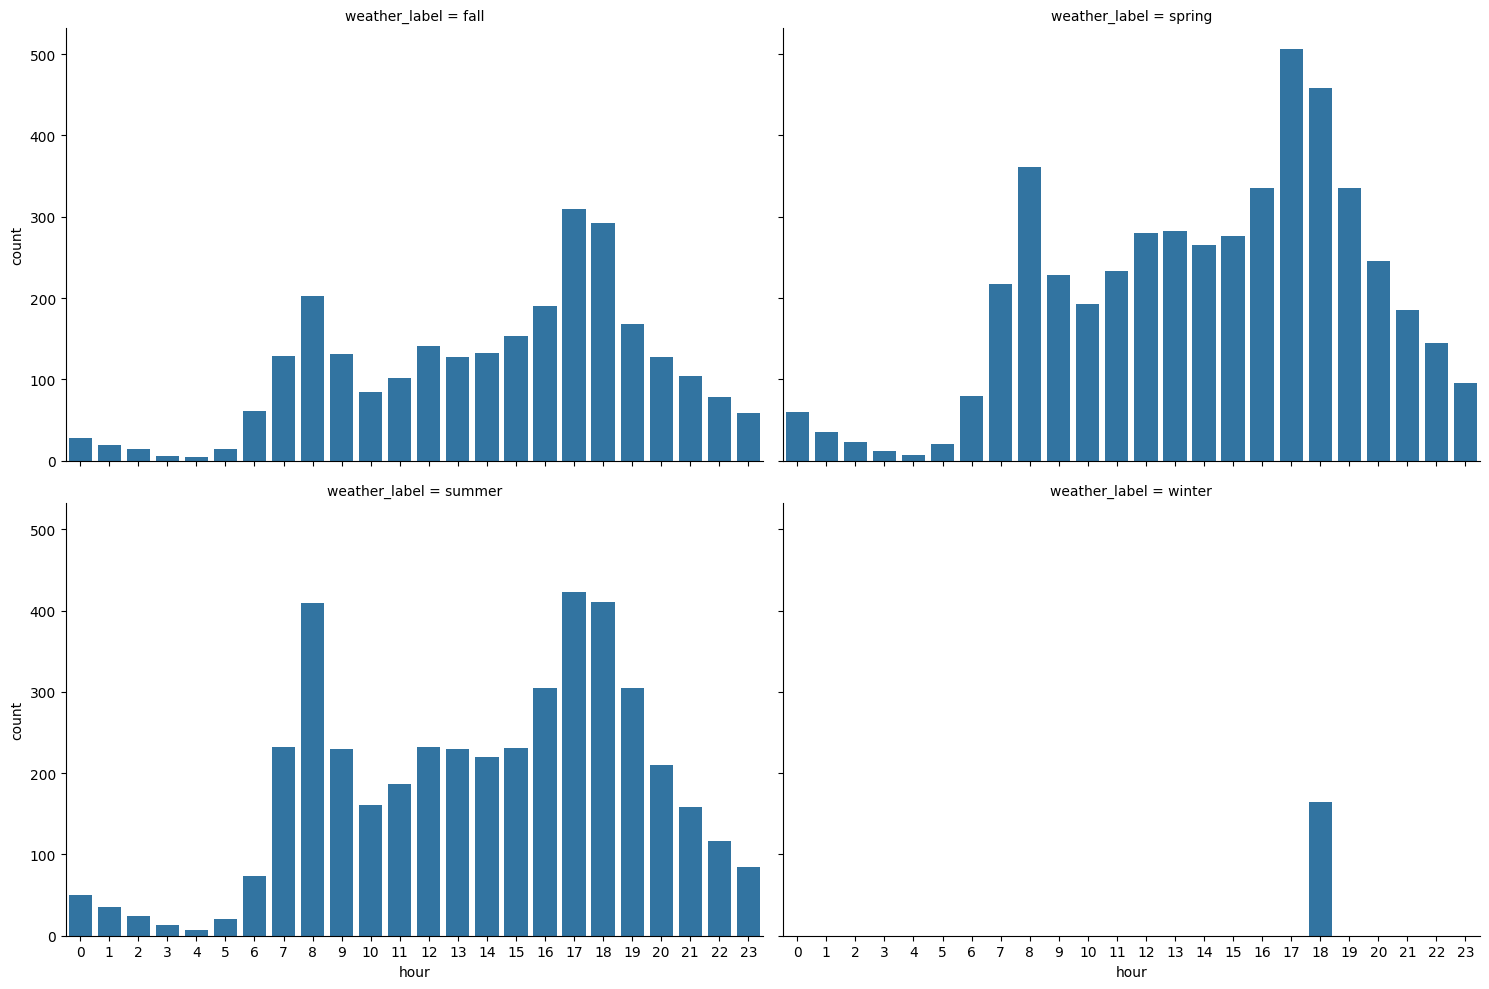

In [41]:
mean_counts = data.groupby(['weather_label','hour'])['count'].mean().reset_index()
g=sns.FacetGrid(mean_counts,col='weather_label',col_wrap=2, height=5, aspect=1.5)
g.map_dataframe(sns.barplot,x='hour',y ='count')

10.Plot the the mean  and the 95% confidence interval of the hourly total rentals 
count versus the period of the day column, which you created in the first part 
of the assignment. Which period of the day has the highest rentals count ? 
Does this peak period differ for working and non-working days ?

<Axes: xlabel='hour', ylabel='count'>

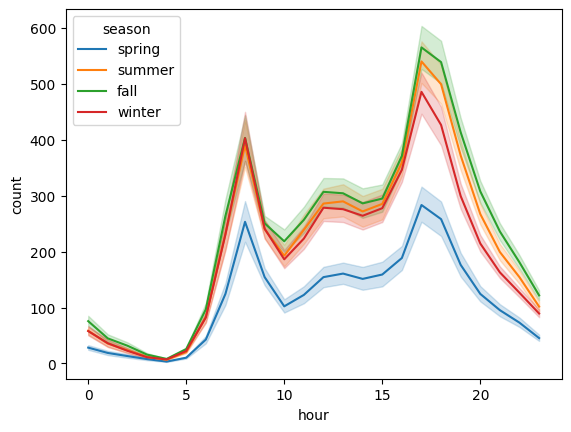

In [42]:
sns.lineplot(data=data,x='hour',y='count',hue='season',)

11.Plot a heatmap for the correlation matrix of the dataset numerical variables. 
What observations can you make ?

<Axes: >

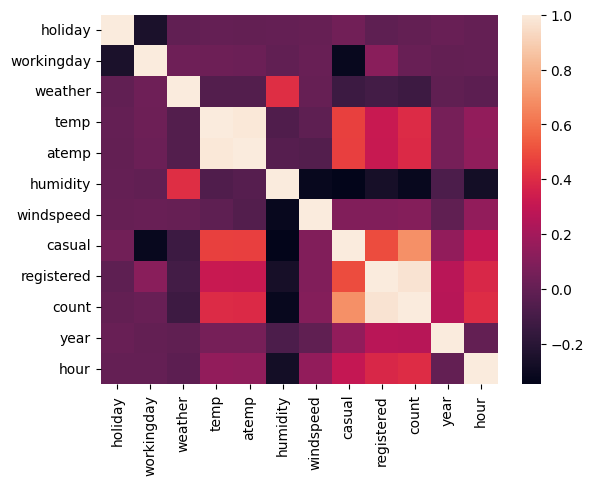

In [46]:
correlation_matrix= numeric_cols.corr()
sns.heatmap(correlation_matrix)

**ANS:**The above correlation heat map show the relation btw the two columns 1 is the highest and 0 is the lowest correlation 
        temp vs atemp as strong correlation<br>
        registered vs count as strong correlation<br>
        casual vs working day as bad correletion,etc<br>
        

